In [1]:
import re, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score, f1_score)
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings("ignore")
os.makedirs("/tmp/mod05", exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})
np.random.seed(42)

CONDITIONS = {
    "Cardiac"  : [
        "heart failure BNP elevated furosemide diuresis ejection fraction reduced cardiomegaly edema IV",
        "STEMI myocardial infarction troponin elevated ST elevation cath lab PCI stent aspirin heparin",
        "atrial fibrillation rate control metoprolol digoxin anticoagulation warfarin apixaban stroke",
        "hypertensive urgency BP elevated labetalol nicardipine end organ damage creatinine troponin",
    ],
    "Pulmonary": [
        "COPD exacerbation bronchospasm albuterol ipratropium methylprednisolone azithromycin oxygen SpO2",
        "community acquired pneumonia consolidation fever WBC antibiotics ceftriaxone blood cultures",
        "pulmonary embolism bilateral CT angiography rivaroxaban heparin DVT RV strain troponin",
        "asthma exacerbation peak flow bronchodilators steroids magnesium sulfate admission ICU",
    ],
    "Diabetes" : [
        "diabetic ketoacidosis glucose anion gap metabolic acidosis insulin drip IV fluids potassium",
        "hypoglycemia glucose altered mental status dextrose glucagon diabetes education carbohydrate",
        "uncontrolled type 2 diabetes HbA1c polyuria polydipsia weight loss metformin GLP-1 SGLT2",
        "diabetic foot infection wound culture debridement surgical amputation vascular IV antibiotics",
    ],
    "Renal"    : [
        "acute kidney injury creatinine elevated fluid resuscitation hold nephrotoxins ACE dialysis",
        "end stage renal disease hemodialysis access fistula potassium hyperkalemia emergent dialysis",
        "nephrotic syndrome proteinuria albumin low edema diuretics renal biopsy FSGS prednisone",
    ],
    "Sepsis"   : [
        "septic shock norepinephrine vasopressor broad spectrum antibiotics vancomycin meropenem lactate ICU",
        "bacteremia Staph aureus MSSA blood cultures positive oxacillin nafcillin endocarditis vegetation",
        "neutropenic fever chemotherapy immunosuppressed filgrastim antifungal fluconazole cultures negative",
    ],
}

def augment(text, noise=0.15):
    words = text.split()
    result = []
    for w in words:
        result.append(w)
        if np. random.rand() < noise:
            result.append(np.random.choice(["assessment", "plan", "patient", "stable", "monitor", "admitted"]))
    return "".join(text)
    
corpus = []
for condition, templates in CONDITIONS.items():
    readmit_prob = {"Cardiac":0.26,"Pulmonary":0.18,"Diabetes":0.21,"Renal":0.23,"Sepsis":0.31}
    for i in range(100):
        base = np.random.choice(templates)
        text = augment(base)
        readmitted = int(np.random.rand() < readmit_prob[condition])
        corpus.append({"text":text,"condition":condition,"readmitted":readmitted,
                       "note_length":len(text.split())})
df = pd.DataFrame(corpus)
print(f"Corpus: {len(df)} notes | Readmission rate: {df.readmitted.mean()*100:.1f}%")
print(df.condition.value_counts())       
                          

Corpus: 500 notes | Readmission rate: 24.0%
condition
Cardiac      100
Pulmonary    100
Diabetes     100
Renal        100
Sepsis       100
Name: count, dtype: int64


## Clinical Stop word & Cleaning

In [2]:
CLINICAL_STOP_WORDS = [
    "patient","pt","the","a","an","is","was","were","been","has","have","had",
    "will","would","could","should","may","might","must","can","do","does","did",
    "and","or","but","with","for","on","at","in","to","of","from","by","as","be",
    "this","that","these","those","it","its","all","any","both","each","few",
    "most","other","some","no","not","only","same","too","very","just",
    "admitted","admission","discharge","plan","assessment","note","hospital",
    "day","follow","given","started","continued","current","status","history",
    "exam","also","during","after","before","within","without","between",
]
def clean_clinical_text(text):
    text = text.lower()
    text = re.sub(r'\b\d+\.?\d*\b', ' ', text)
    text = re.sub(r'[^a-z0-9\s-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df["clean_text"] = df["text"].apply(clean_clinical_text)
print("Sample cleaned text: ")
print(df["clean_text"].iloc[0][:200])


Sample cleaned text: 
atrial fibrillation rate control metoprolol digoxin anticoagulation warfarin apixaban stroke


## Feature Extraction Comparison

In [6]:
X = df["clean_text"]; y_cond = df["condition"]; y_re = df["readmitted"]
X_tr, X_te, yc_tr, yc_te, yr_tr, yr_te = train_test_split(
    X, y_cond, y_re, test_size=0.20, stratify=y_cond, random_state=42)
feature_configs = {
    "BoW (unigrams)"    : CountVectorizer(stop_words=CLINICAL_STOP_WORDS,
max_features=3000),
    "TF-IDF (unigrams)"  : TfidfVectorizer(stop_words=CLINICAL_STOP_WORDS,
 max_features=3000),
    "TF-IDF (1-2 grams)" : TfidfVectorizer(stop_words=CLINICAL_STOP_WORDS, ngram_range=(1,2),
max_features = 5000),
    "TF-IDF (char 3-5)"  : TfidfVectorizer(analyzer ="char_wb", ngram_range=(3,5),
max_features = 5000)
}
skf = StratifiedKFold(5, shuffle=True, random_state=42)
print("Feature comparision - 5-fold CV:\n")
feat_results = []
for name, vect in feature_configs.items():
    pipe = Pipeline([("v", vect), ("c",LogisticRegression(C=1,max_iter=1000,random_state=42,multi_class="multinomial"))])
    f1_cond = cross_val_score(pipe, X, y_cond, cv=skf, scoring="f1_weighted").mean()
    auc_re   = cross_val_score(pipe, X, y_re,   cv=skf, scoring="roc_auc").mean()
    feat_results.append({"Feature":name,"Condition F1":round(f1_cond,4),"Readmit AUC":round(auc_re,4)})
    print(f"  {name:28s}: Condition F1={f1_cond:.4f} | Readmit AUC={auc_re:.4f}")
display(pd.DataFrame(feat_results))                  

Feature comparision - 5-fold CV:

  BoW (unigrams)              : Condition F1=1.0000 | Readmit AUC=0.5447
  TF-IDF (unigrams)           : Condition F1=1.0000 | Readmit AUC=0.5452
  TF-IDF (1-2 grams)          : Condition F1=1.0000 | Readmit AUC=0.5454
  TF-IDF (char 3-5)           : Condition F1=1.0000 | Readmit AUC=0.5474


,Feature,Condition F1,Readmit AUC
0,BoW (unigrams),1.0,0.5447
1,TF-IDF (unigrams),1.0,0.5452
2,TF-IDF (1-2 grams),1.0,0.5454
3,TF-IDF (char 3-5),1.0,0.5474


## Condition Classification - Full Evaluation

Condition Classification Report
              precision    recall  f1-score   support

     Cardiac       1.00      1.00      1.00        20
    Diabetes       1.00      1.00      1.00        20
   Pulmonary       1.00      1.00      1.00        20
       Renal       1.00      1.00      1.00        20
      Sepsis       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



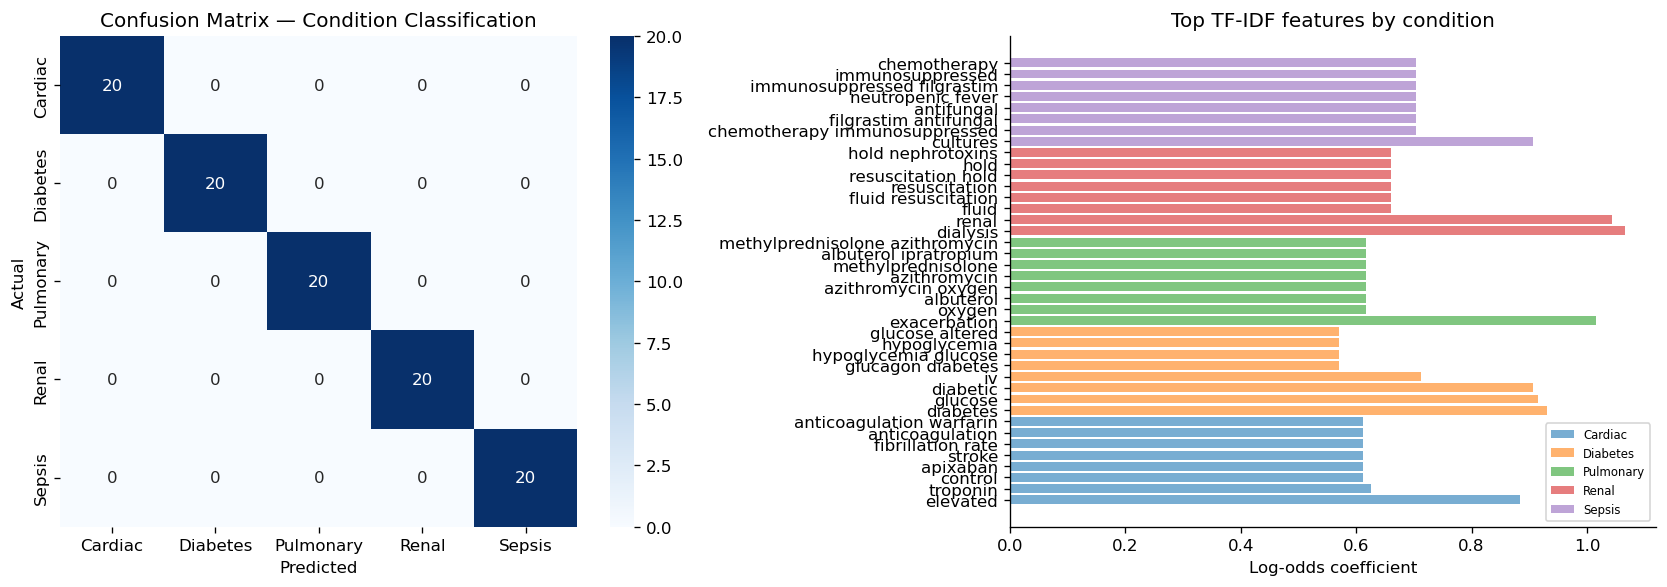

In [14]:
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, f1_score, confusion_matrix)
vect = TfidfVectorizer(stop_words=CLINICAL_STOP_WORDS, ngram_range=(1,2),
                        max_features=5000, sublinear_tf=True)
clf  = LogisticRegression(C=1, max_iter=1000, random_state=42, multi_class="multinomial")
pipe = Pipeline([("v",vect),("c",clf)])
pipe.fit(X_tr, yc_tr)
yc_pred = pipe.predict(X_te)

print("Condition Classification Report")
print(classification_report(yc_te, yc_pred))

classes = sorted(y_cond.unique())
cm = confusion_matrix(yc_te, yc_pred, labels=classes)
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Condition Classification")

fn = pipe.named_steps["v"].get_feature_names_out()
coefs = pipe.named_steps["c"].coef_
for i, cond in enumerate(pipe.named_steps["c"].classes_):
    top_idx = np.argsort(coefs[i])[-8:]
    axes[1].barh([fn[j] for j in top_idx][::-1], [coefs[i][j] for j in top_idx][::-1],
                 alpha=0.6, label=cond)
axes[1].set_xlabel("Log-odds coefficient")
axes[1].set_title("Top TF-IDF features by condition")
axes[1].legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig("/tmp/mod05/tfidf_classification.png", bbox_inches="tight"); plt.show()